# 📊 Análise Exploratória de Dados (EDA)

## 🧠 Contexto do Problema

Neste projeto, buscamos prever o **valor de um seguro de saúde** com base em características individuais dos clientes, como idade, IMC, hábito de fumar, entre outras variáveis.

Trata-se de um problema de **regressão supervisionada**, onde o objetivo é estimar um valor numérico contínuo (`charges`).

---

## 🎯 Objetivo da Análise

A Análise Exploratória de Dados (EDA) tem como objetivo:

- Entender a estrutura do dataset  
- Identificar padrões e relações entre as variáveis  
- Detectar possíveis outliers e inconsistências  
- Avaliar o impacto das features no valor do seguro  

---

## 🔍 O que será explorado

Durante esta análise, iremos:

- Analisar a distribuição das variáveis  
- Investigar correlações com o valor do seguro  
- Comparar grupos (ex: fumantes vs não fumantes)  
- Extrair insights que auxiliem na construção do modelo  

---

## 🚀 Importância

A EDA é uma etapa fundamental para:
- orientar o pré-processamento dos dados  
- selecionar variáveis relevantes  
- melhorar a performance do modelo final  

---

👉 Ao final, teremos uma compreensão mais clara dos fatores que influenciam o custo do seguro.

## Importação de Bibliotecas e Configurações iniciais

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set(style="whitegrid")

## Contexto e carregamento dos Dados

Antes de iniciar a análise, é importante compreender **a estrutura e a qualidade dos dados disponíveis**. Nesta etapa, iremos carregar a base de dados e realizar uma primeira inspeção para entender melhor suas características.

Serão analisados aspectos como:

- as **colunas presentes no dataset** e o significado de cada variável;
- o **tamanho da base de dados** (quantidade de linhas e colunas);
- a existência de **valores nulos ou ausentes**;
- a presença de **registros duplicados**;
- e a **tradução ou padronização dos nomes das colunas**, quando necessário, para facilitar a interpretação durante a análise.

Essa exploração inicial é essencial para garantir que os dados estejam organizados e adequados para as próximas etapas da análise.

In [ ]:
# Importando a Base de Dados e Lendo os 5 primeiros registros
dados = pd.read_csv('/content/insurance.csv')
dados.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Verificando as informações de cada coluna do Dataset
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Verificando o tamanho do dataset (linhas, colunas)
print(f'Tamanho do Dataset (linhas, colunas) : {dados.shape}')

Tamanho do Dataset (linhas, colunas) : (1338, 7)


In [ ]:
# Verificando a quantidade de dados nulos
print(f'Total de dados nulos no Dataset : {dados.isnull().sum().sum()}')

Total de dados nulos no Dataset : 0


In [ ]:
# Verificando o total de dados duplicados no Dataset
print(f'Total de dados duplicados no Dataset : {dados.duplicated().sum()}')

Total de dados duplicados no Dataset : 1


In [ ]:
dados = dados.drop_duplicates()
print(f'Total de dados duplicados no Dataset : {dados.duplicated().sum()}')

Total de dados duplicados no Dataset : 0


In [ ]:
# Fazendo a tradução das colunas para um melhor entendimento
dados.columns = ['idade', 'sexo', 'imc', 'filhos', 'fumante', 'região', 'valor_seguro']
dados.head()

,idade,sexo,imc,filhos,fumante,região,valor_seguro
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Panorama geral do Valor do Seguro

Nesta etapa foi realizada uma **análise descritiva inicial do valor do seguro** para compreender melhor o comportamento geral dos dados.

Primeiramente, foi utilizada a função `describe()` para gerar **estatísticas descritivas** das principais variáveis numéricas do conjunto de dados, como **idade**, **imc**, **filhos** e **valor_seguro**. Essa análise apresenta métricas como média, desvio padrão, valores mínimos e máximos, além dos quartis, permitindo ter uma visão geral da distribuição dos dados.

Em seguida, foi construído um **histograma do valor do seguro** utilizando `sns.histplot()`, com o objetivo de observar a **distribuição e frequência dos valores**. O gráfico mostra que a maior parte dos seguros está concentrada em valores mais baixos, enquanto valores muito altos aparecem com menor frequência, formando uma distribuição assimétrica à direita.

Por fim, foi gerado um **boxplot do valor do seguro**, que permite visualizar a **mediana, a dispersão dos dados e a presença de outliers**. O gráfico evidencia que existem diversos valores extremos mais altos, indicando que alguns indivíduos possuem seguros significativamente mais caros em comparação com a maioria.

Essa análise inicial ajuda a entender o comportamento geral da variável **valor_seguro**, servindo como base para as análises exploratórias realizadas nas etapas seguintes.

In [ ]:
# Verificando a estatística descritiva do dataframe
dados.describe().round(2)

,idade,imc,filhos,valor_seguro
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


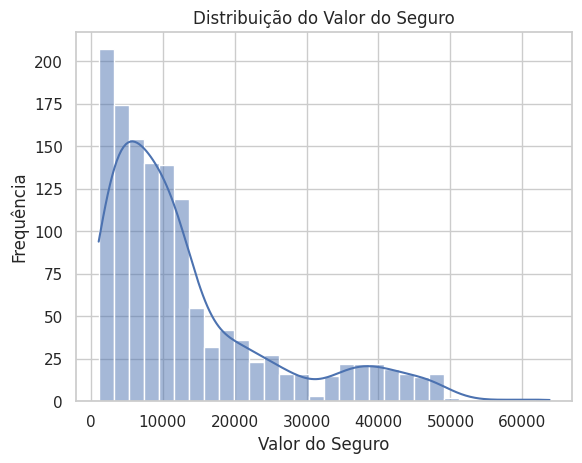

In [ ]:
# Visualizando o Histograma do Valor do Seguro - verificando suas frequências
sns.histplot(data=dados, x='valor_seguro', bins=30, kde=True)
plt.title('Distribuição do Valor do Seguro')
plt.xlabel('Valor do Seguro')
plt.ylabel('Frequência')
plt.show()

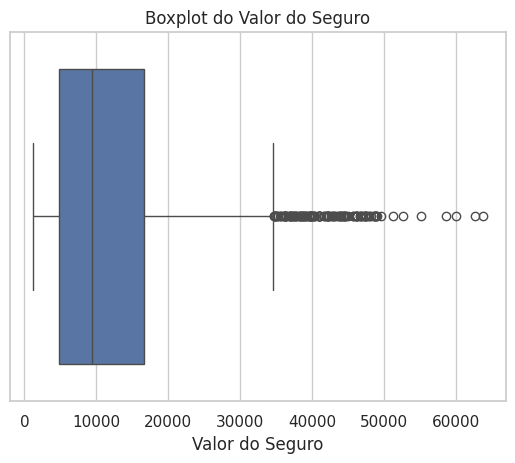

In [ ]:
# Visualizando o Boxplot
sns.boxplot(data=dados, x='valor_seguro')
plt.title('Boxplot do Valor do Seguro')
plt.xlabel('Valor do Seguro')
plt.show()

In [ ]:
dados['valor_seguro'].describe().round(2)

,valor_seguro
count,1337.00
mean,13279.12
std,12110.36
min,1121.87
25%,4746.34
50%,9386.16
75%,16657.72
max,63770.43


## Classificação do Valor do Seguro

Nesta etapa foi realizada a **classificação dos valores de seguro** em diferentes categorias de preço, com o objetivo de facilitar a análise e visualização dos dados.

Primeiramente, foi criada uma nova coluna chamada **`classe`** no dataframe `dados`. Para isso, foi utilizada a função `pd.cut()`, que divide valores numéricos em intervalos (bins). O campo **`valor_seguro`** foi segmentado nas seguintes faixas:

- **Barato:** 0 até 10.000  
- **Médio:** 10.000 até 20.000  
- **Caro:** 20.000 até 35.000  
- **Muito Caro:** acima de 35.000  

Com essa classificação, cada registro passou a receber um rótulo correspondente ao intervalo em que seu valor de seguro se encontra.

Em seguida, foi feita a **contagem de registros em cada classe** utilizando `value_counts()`, permitindo observar a distribuição dos dados entre as categorias. Foi possível identificar que a maioria dos seguros está classificada como **Barato**, enquanto **Muito Caro** possui a menor quantidade de registros.

Depois disso, foram geradas duas visualizações para apoiar a análise:

- **Gráfico de barras:** mostra a **média do valor do seguro em cada classificação**, permitindo comparar como os valores médios aumentam entre as categorias.
- **Boxplot:** apresenta a **distribuição dos valores de seguro dentro de cada classe**, mostrando mediana, dispersão e possíveis outliers.

Essas visualizações ajudam a entender melhor o comportamento dos valores de seguro em cada faixa de classificação e a validar a segmentação realizada.

In [ ]:
dados['classe'] = pd.cut(dados['valor_seguro'],
                         bins=[0., 10000., 20000., 35000., np.inf],
                         labels=['Barato', 'Médio', 'Caro', 'Muito Caro'])
dados.head()

,idade,sexo,imc,filhos,fumante,região,valor_seguro,classe
0,19,female,27.900,0,yes,southwest,16884.92400,Médio
1,18,male,33.770,1,no,southeast,1725.55230,Barato
2,28,male,33.000,3,no,southeast,4449.46200,Barato
3,33,male,22.705,0,no,northwest,21984.47061,Caro
4,32,male,28.880,0,no,northwest,3866.85520,Barato


In [ ]:
# Verificando a contagem de cada classificador
dados['classe'].value_counts().sort_values()

,count
classe,
Muito Caro,133
Caro,140
Médio,353
Barato,711


In [ ]:
media_valor = dados.groupby('classe')['valor_seguro'].mean().sort_values(ascending=False).round(2)
media_valor

/tmp/ipykernel_151/2264214877.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_valor = dados.groupby('classe')['valor_seguro'].mean().sort_values(ascending=False).round(2)


,valor_seguro
classe,
Muito Caro,42435.38
Caro,25957.36
Médio,13513.71
Barato,5212.25


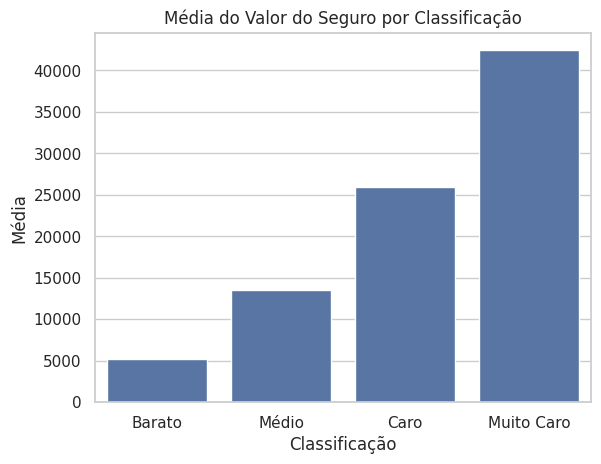

In [ ]:
sns.barplot(x=media_valor.index, y=media_valor.values)
plt.title('Média do Valor do Seguro por Classificação')
plt.xlabel('Classificação')
plt.ylabel('Média')
plt.show()

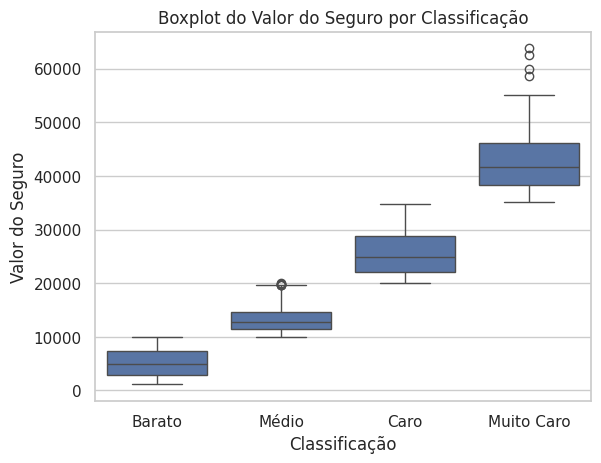

In [ ]:
sns.boxplot(data=dados, x='classe', y='valor_seguro')
plt.title('Boxplot do Valor do Seguro por Classificação')
plt.xlabel('Classificação')
plt.ylabel('Valor do Seguro')
plt.show()

## Correlação entre as Variáveis

Nesta etapa foi realizada uma análise de **correlação entre algumas variáveis do conjunto de dados**, com o objetivo de identificar quais fatores possuem maior relação com o **valor do seguro**.

Primeiramente, a variável **fumante** foi convertida de categórica para numérica, utilizando um mapeamento onde `yes = 1` e `no = 0`. Essa transformação é necessária para que a variável possa ser utilizada em cálculos de correlação.

Em seguida, foi calculada a **matriz de correlação** entre as variáveis **idade**, **fumante** e **valor_seguro** utilizando o método `corr()`. O resultado foi visualizado através de um **heatmap**, que facilita a interpretação dos coeficientes de correlação.

Os resultados indicam que:

- A variável **fumante** apresenta uma **forte correlação positiva com o valor do seguro (0.79)**, indicando que pessoas fumantes tendem a possuir seguros significativamente mais caros.
- A **idade** possui uma **correlação positiva moderada com o valor do seguro (0.30)**, sugerindo que o aumento da idade está associado a um aumento gradual no custo do seguro.
- A correlação entre **idade e fumante** é praticamente inexistente (-0.03), indicando que essas variáveis não possuem relação significativa entre si.

Para complementar a análise, foram gerados **gráficos de regressão (regplot)** mostrando a relação entre **idade e valor do seguro** e entre **fumante e valor do seguro**. Esses gráficos permitem visualizar a tendência de crescimento do valor do seguro em função dessas variáveis.

De forma geral, os resultados reforçam que **o hábito de fumar é um dos fatores mais impactantes no aumento do preço do seguro**, enquanto a **idade também exerce influência, porém de maneira mais moderada**.

In [ ]:
map_fumante = {
    'yes' : 1,
    'no' : 0
}

dados['fumante'] = dados['fumante'].map(map_fumante)
dados['fumante'].unique()

array([1, 0])

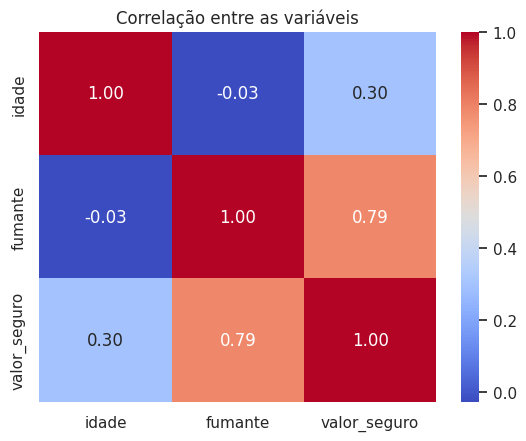

In [ ]:
corr = dados[['idade', 'fumante', 'valor_seguro']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre as variáveis')
plt.show()

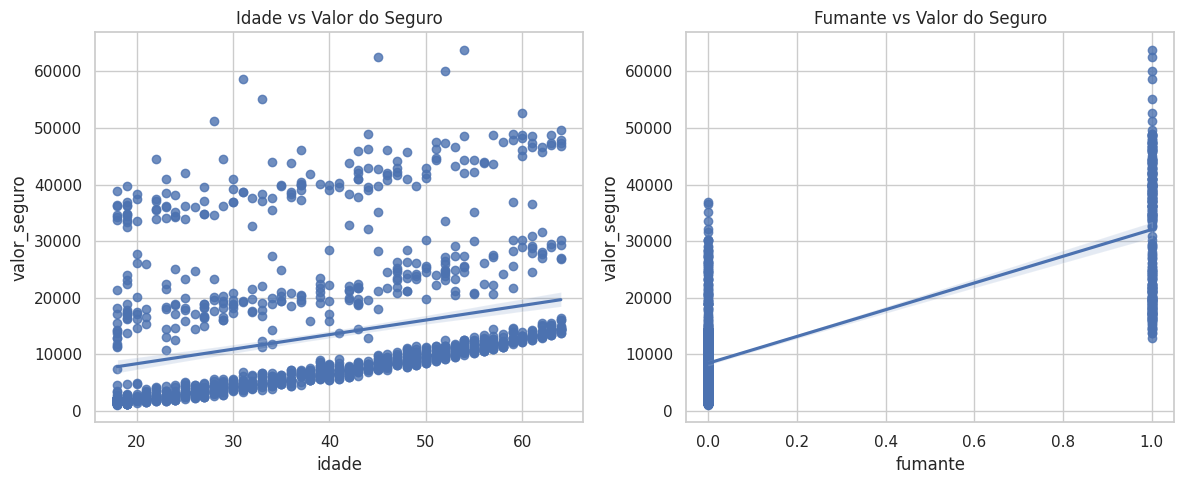

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.regplot(data=dados, x='idade', y='valor_seguro', ax=ax[0])
ax[0].set_title('Idade vs Valor do Seguro')

sns.regplot(data=dados, x='fumante', y='valor_seguro', ax=ax[1])
ax[1].set_title('Fumante vs Valor do Seguro')

plt.tight_layout()
plt.show()

## Fatores mais críticos para o preço do seguro

Nesta etapa foi realizada uma análise exploratória para identificar **quais variáveis influenciam diretamente o valor do seguro**. Para isso, foram utilizados **gráficos de Boxplot e Violinplot**, que permitem visualizar a distribuição dos dados, a mediana, a dispersão e possíveis valores extremos.

### Análise da variável idade

Foram gerados um **Boxplot** e um **Violinplot** relacionando **idade** com a **classe do valor do seguro**.  

Os gráficos mostram que, de modo geral, **valores de seguro mais altos estão associados a idades maiores**. Classes como **Caro** e **Muito Caro** apresentam uma faixa etária mais elevada e maior dispersão, indicando que o aumento da idade tende a elevar o custo do seguro.

### Análise da variável fumante

Também foram gerados **Boxplot** e **Violinplot** comparando o **valor do seguro** entre **fumantes e não fumantes**.

Os gráficos evidenciam uma diferença significativa entre os grupos. Pessoas **fumantes** apresentam valores de seguro **consideravelmente mais altos** e maior variabilidade, enquanto **não fumantes** tendem a ter seguros com valores menores.



In [ ]:
dados.head()

,idade,sexo,imc,filhos,fumante,região,valor_seguro,classe
0,19,female,27.900,0,1,southwest,16884.92400,Médio
1,18,male,33.770,1,0,southeast,1725.55230,Barato
2,28,male,33.000,3,0,southeast,4449.46200,Barato
3,33,male,22.705,0,0,northwest,21984.47061,Caro
4,32,male,28.880,0,0,northwest,3866.85520,Barato


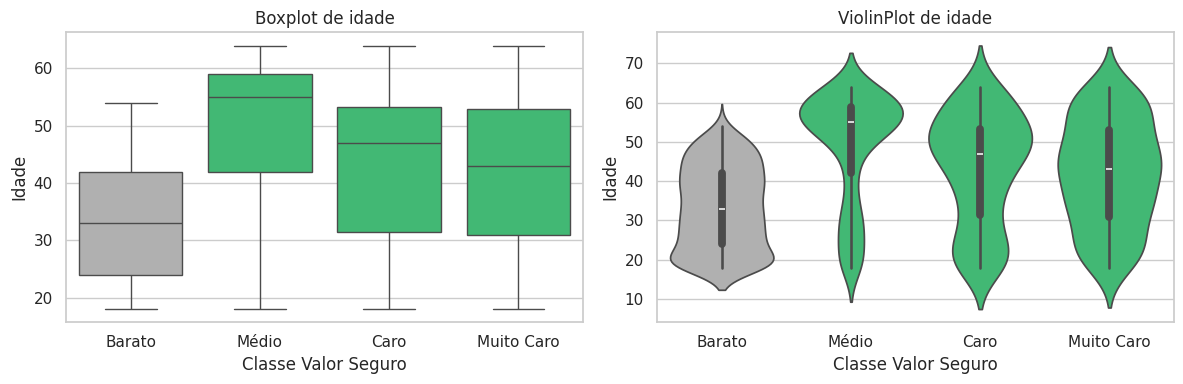

In [ ]:
# Visualizando o Boxplot e fazendo a comparação dos fatores mais críticos
fig, ax = plt.subplots(1, 2, figsize=(12,4))

palette = {
    'Barato': '#b0b0b0',
    'Médio': '#2ecc71',
    'Caro': '#2ecc71',
    'Muito Caro': '#2ecc71'
}

order = ['Barato', 'Médio', 'Caro', 'Muito Caro']
sns.boxplot(data=dados, x='classe', y='idade', order=order, ax=ax[0],palette=palette , legend=False, hue='classe')
ax[0].set_title(f'Boxplot de idade')
ax[0].set_xlabel('Classe Valor Seguro')
ax[0].set_ylabel('Idade')

sns.violinplot(data=dados, x='classe', y='idade', order=order, ax=ax[1],palette=palette, legend=False, hue='classe')
ax[1].set_title(f'ViolinPlot de idade')
ax[1].set_xlabel('Classe Valor Seguro')
ax[1].set_ylabel('Idade')

plt.tight_layout()
plt.show()

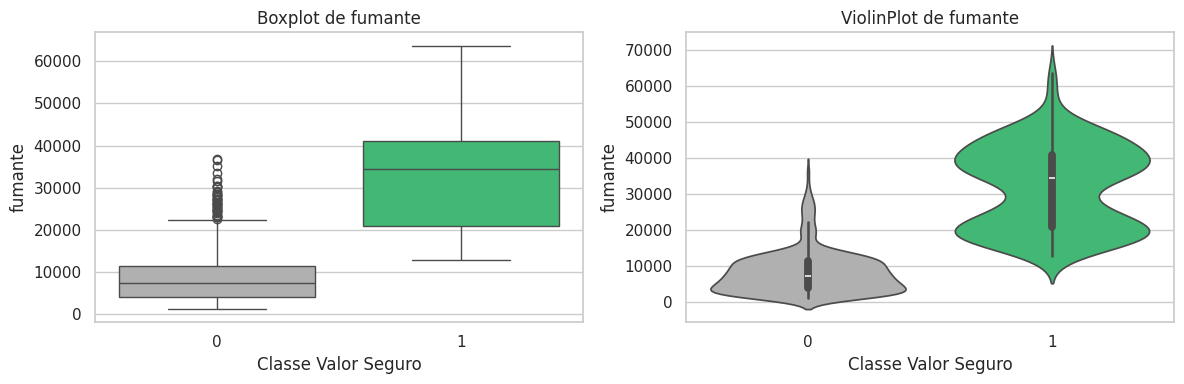

In [ ]:
# Visualizando o Boxplot e fazendo a comparação dos fatores mais críticos
fig, ax = plt.subplots(1, 2, figsize=(12,4))

palette = {
    0: '#b0b0b0',
    1: '#2ecc71'
}

sns.boxplot(data=dados, x='fumante', y='valor_seguro',palette=palette, ax=ax[0], legend=False, hue='fumante')
ax[0].set_title(f'Boxplot de fumante')
ax[0].set_xlabel('Classe Valor Seguro')
ax[0].set_ylabel('fumante')

sns.violinplot(data=dados, x='fumante', y='valor_seguro',palette=palette, ax=ax[1],legend=False, hue='fumante')
ax[1].set_title(f'ViolinPlot de fumante')
ax[1].set_xlabel('Classe Valor Seguro')
ax[1].set_ylabel('fumante')

plt.tight_layout()
plt.show()

### 📌 Conclusão Geral

A análise exploratória evidenciou que **idade e hábito de fumar são os principais fatores associados ao aumento do valor do seguro**. 

Observou-se que o custo tende a crescer com o avanço da idade, refletindo o aumento natural de riscos à saúde. No entanto, o impacto do **tabagismo se destaca ainda mais**, apresentando diferenças expressivas entre fumantes e não fumantes, tanto em nível médio quanto na variabilidade dos valores.

Esses resultados reforçam a importância dessas variáveis para a modelagem preditiva, indicando que elas devem ter papel central no treinamento do modelo. Além disso, a análise fornece uma base sólida para as próximas etapas, como o pré-processamento e a construção de modelos mais precisos.

👉 Em resumo, os dados confirmam que fatores ligados ao risco à saúde são determinantes diretos no custo do seguro.